In [1]:
from IPython.display import display, Markdown

display(Markdown("""
# PENGOLAHAN DATA TABULAR PARAMETER LINGKUNGAN UNTUK REKOMENDASI TANAMAN

**Nama          : Galuh Kurnia Pratama**
**NIM           : 23030224105**
**Kelas         : Fisika B 2023**
**Mata Kuliah   : Instrumentasi Cerdas**
"""))

# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Membaca dataset
df = pd.read_csv("assets/crop_recommendation.csv")
print("Dataset berhasil dimuat.")

# Melihat dataset
df.head()
df.tail()

print("Jumlah baris dan kolom:", df.shape)
print("Kolom:", df.columns.tolist())

df.info()




# PENGOLAHAN DATA TABULAR PARAMETER LINGKUNGAN UNTUK REKOMENDASI TANAMAN

**Nama          : Galuh Kurnia Pratama**
**NIM           : 23030224105**
**Kelas         : Fisika B 2023**
**Mata Kuliah   : Instrumentasi Cerdas**


Dataset berhasil dimuat.
Jumlah baris dan kolom: (2200, 8)
Kolom: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [2]:
# Pemeriksaan kualitas data
print("Missing value:")
print(df.isnull().sum())

jumlah_duplikat = df.duplicated().sum()
print("Jumlah baris duplikat:", jumlah_duplikat)

print("Jumlah kategori tanaman:", df["label"].nunique())
print(df["label"].value_counts())


Missing value:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Jumlah baris duplikat: 0
Jumlah kategori tanaman: 22
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


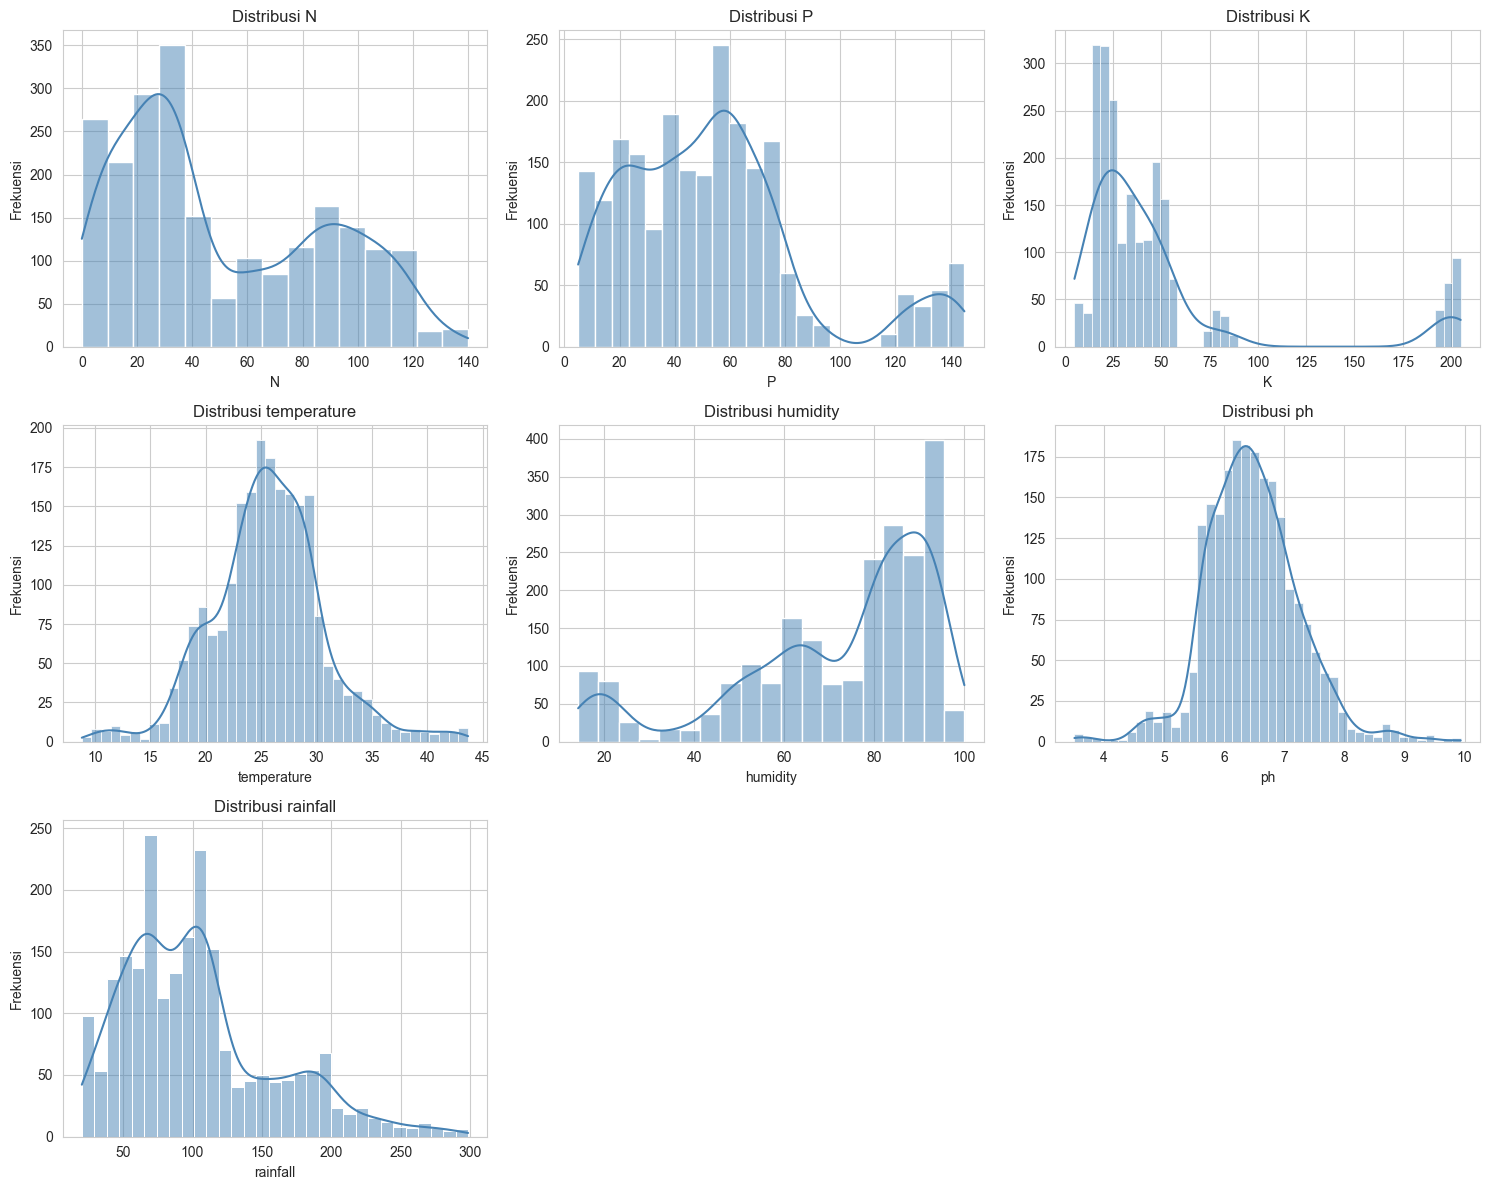

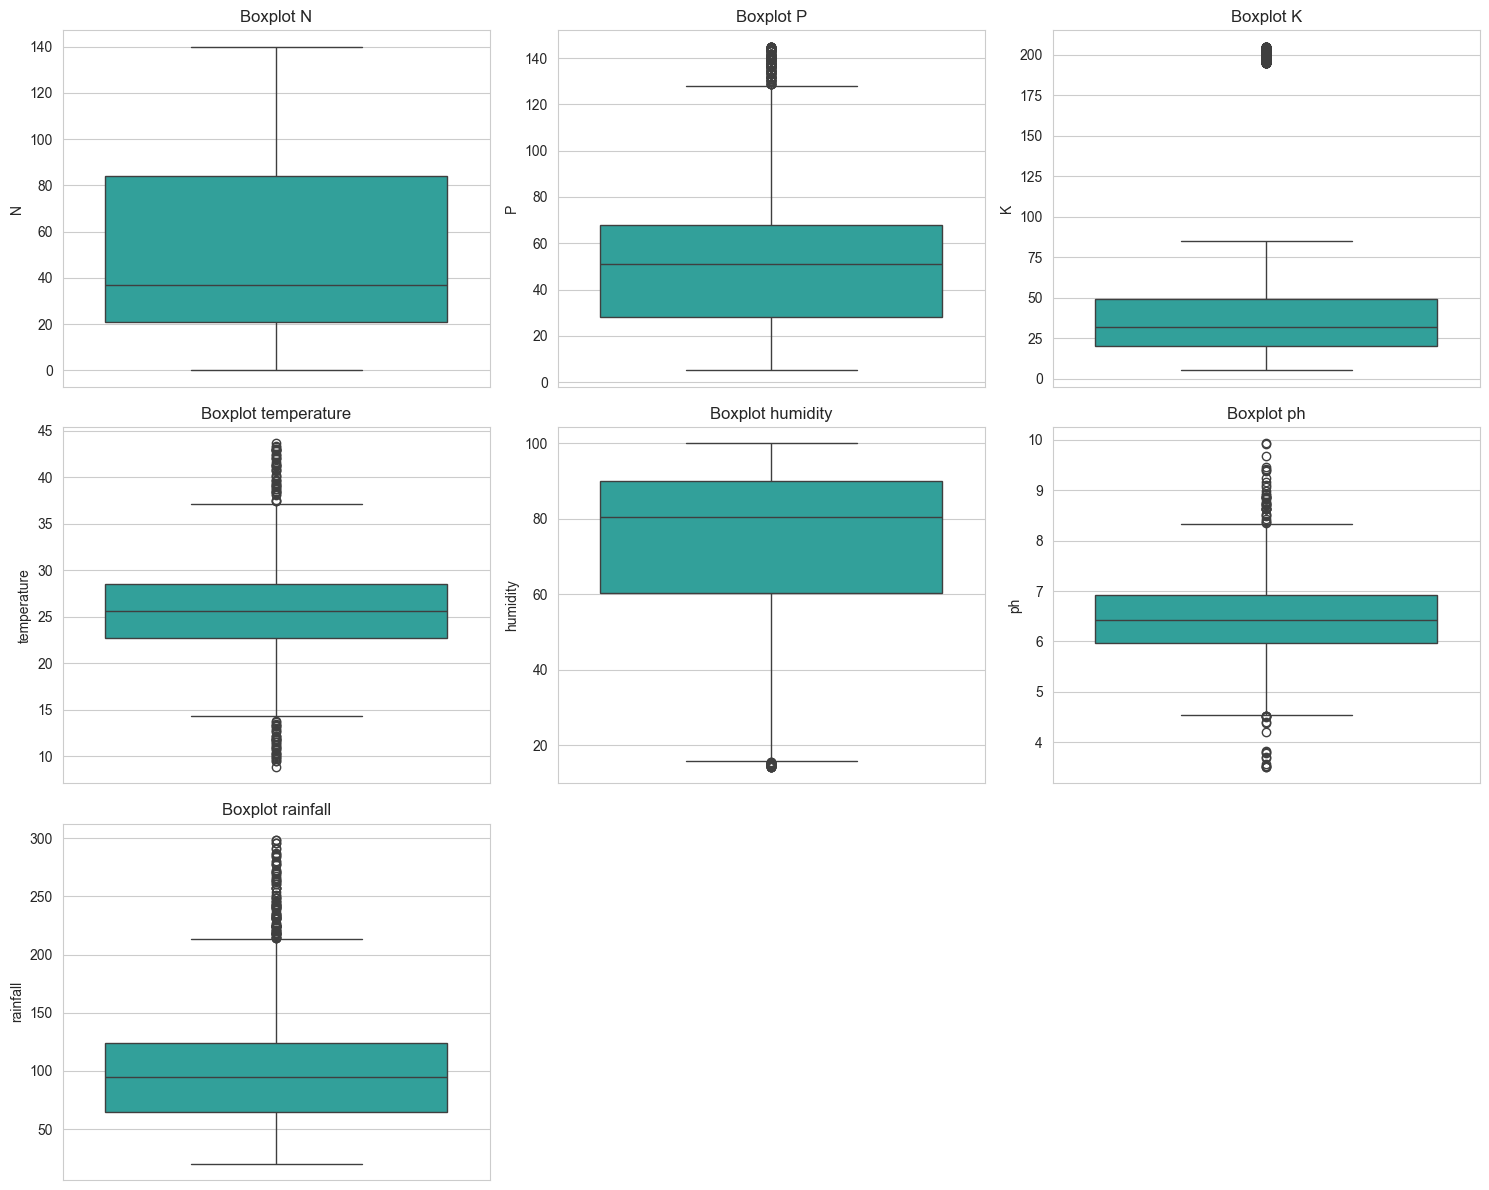

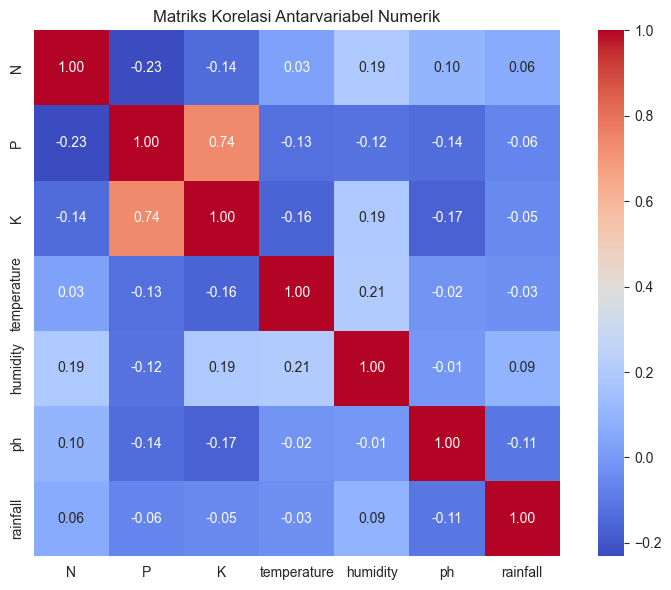

In [3]:
# Statistik deskriptif
df.describe()

# Variabel numerik
kolom_numerik = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

# Distribusi variabel numerik
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    sns.histplot(df[kolom], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribusi {kolom}")
    axes[i].set_xlabel(kolom)
    axes[i].set_ylabel("Frekuensi")

for j in range(len(kolom_numerik), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Boxplot
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    sns.boxplot(y=df[kolom], ax=axes[i], color="lightseagreen")
    axes[i].set_title(f"Boxplot {kolom}")

for j in range(len(kolom_numerik), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Korelasi
matriks_korelasi = df[kolom_numerik].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriks_korelasi,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar=True
)
plt.title("Matriks Korelasi Antarvariabel Numerik")
plt.tight_layout()
plt.show()

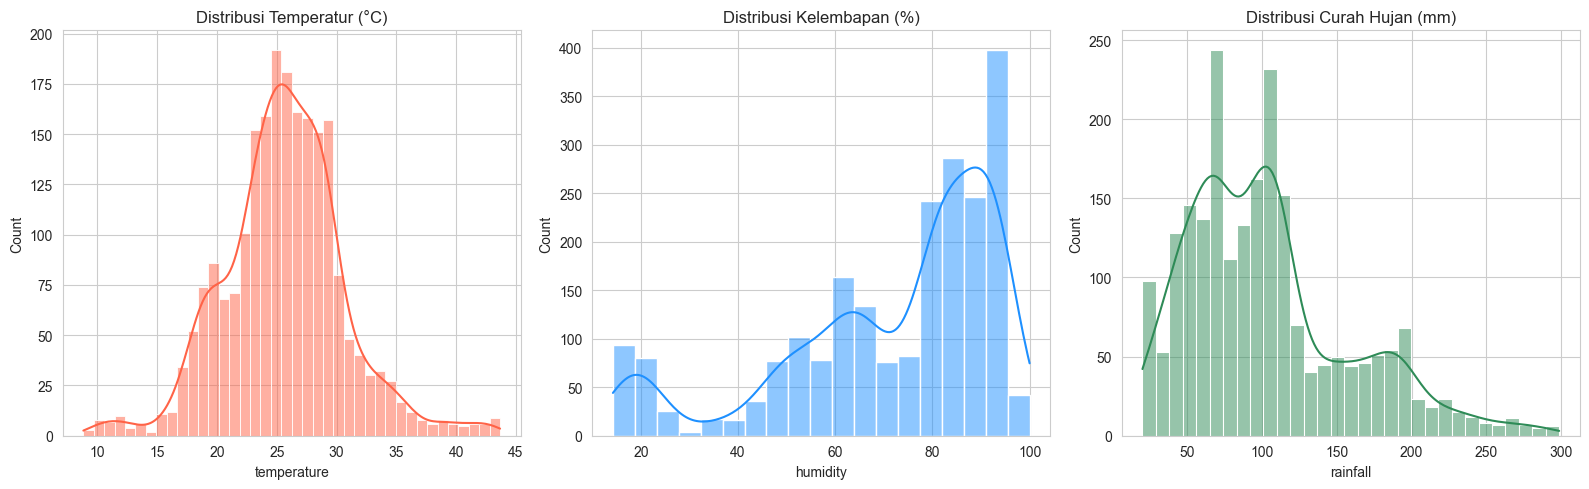

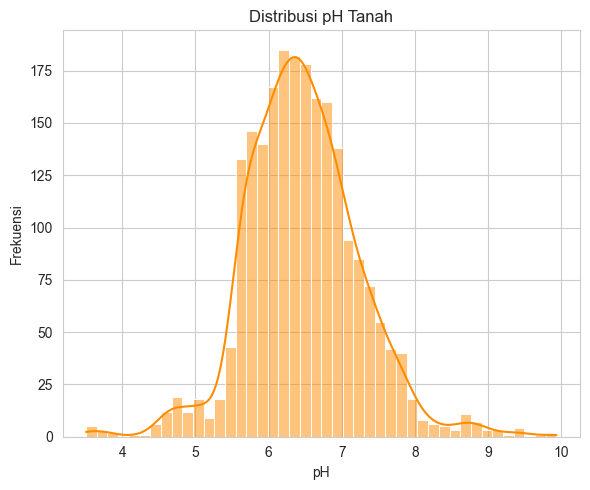

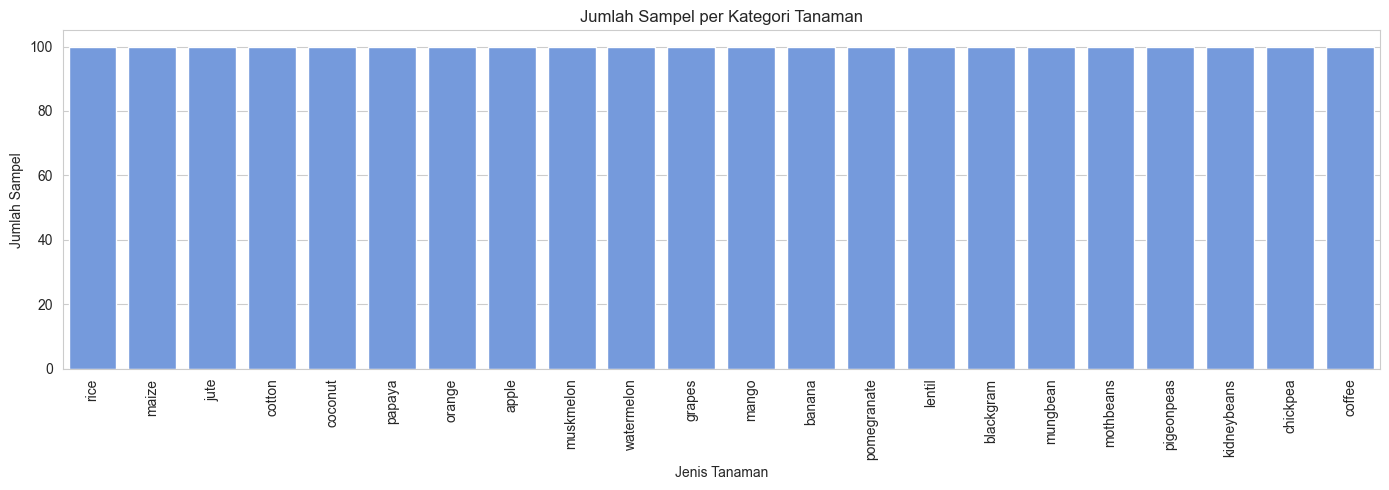

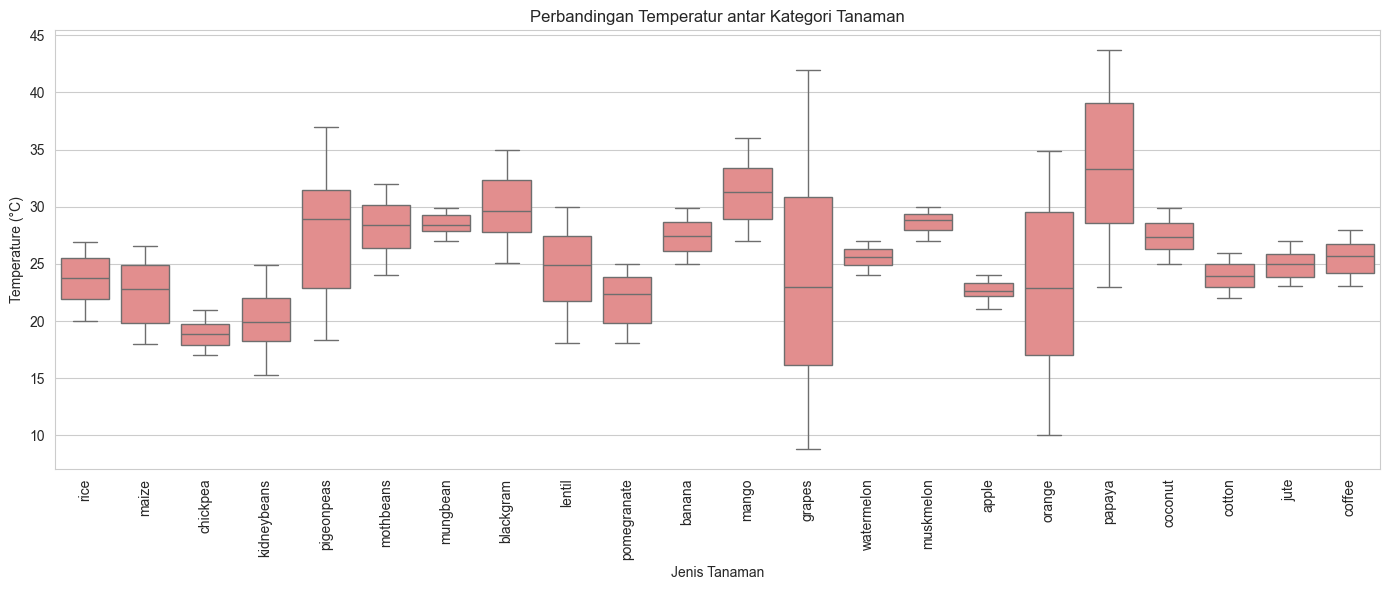

In [4]:
# Parameter lingkungan
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df["temperature"], kde=True, ax=axes[0], color="tomato")
axes[0].set_title("Distribusi Temperatur (°C)")

sns.histplot(df["humidity"], kde=True, ax=axes[1], color="dodgerblue")
axes[1].set_title("Distribusi Kelembapan (%)")

sns.histplot(df["rainfall"], kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Distribusi Curah Hujan (mm)")

plt.tight_layout()
plt.show()

# Distribusi pH
plt.figure(figsize=(6, 5))

sns.histplot(df["ph"], kde=True, color="darkorange")

plt.title("Distribusi pH Tanah")
plt.xlabel("pH")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# Jumlah sampel per kategori
plt.figure(figsize=(14, 5))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index,
    color="cornflowerblue"
)

plt.title("Jumlah Sampel per Kategori Tanaman")
plt.xlabel("Jenis Tanaman")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Temperatur per kategori
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="label",
    y="temperature",
    color="lightcoral"
)

plt.title("Perbandingan Temperatur antar Kategori Tanaman")
plt.xlabel("Jenis Tanaman")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

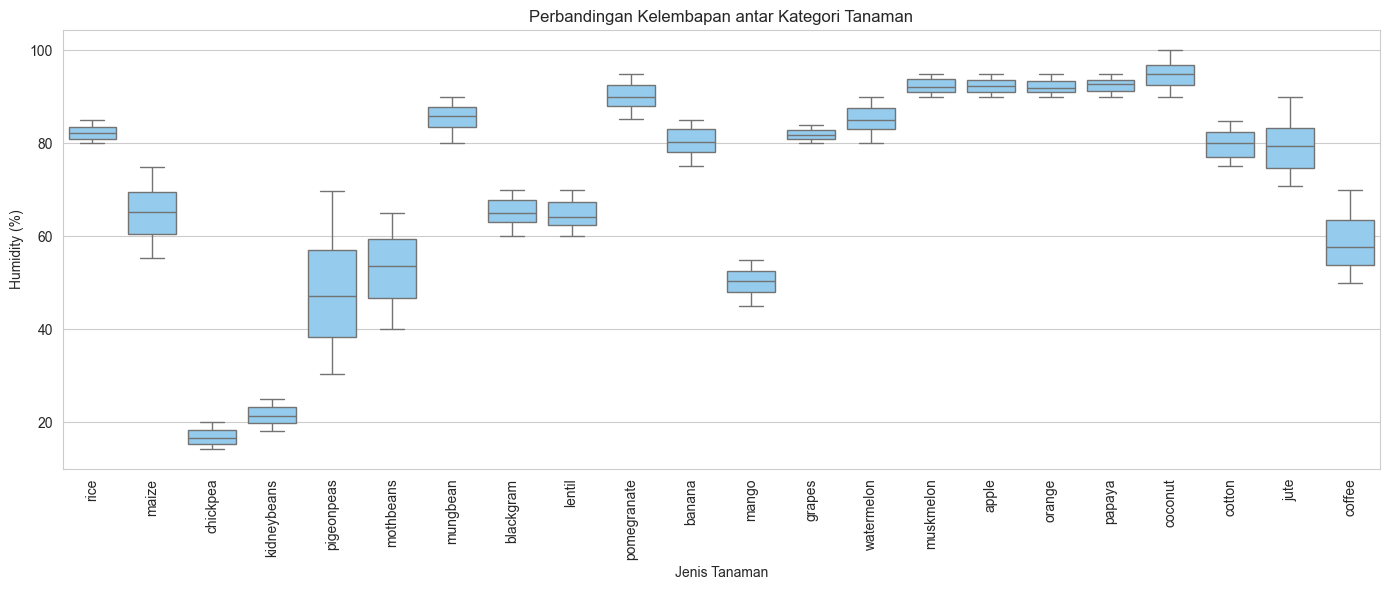

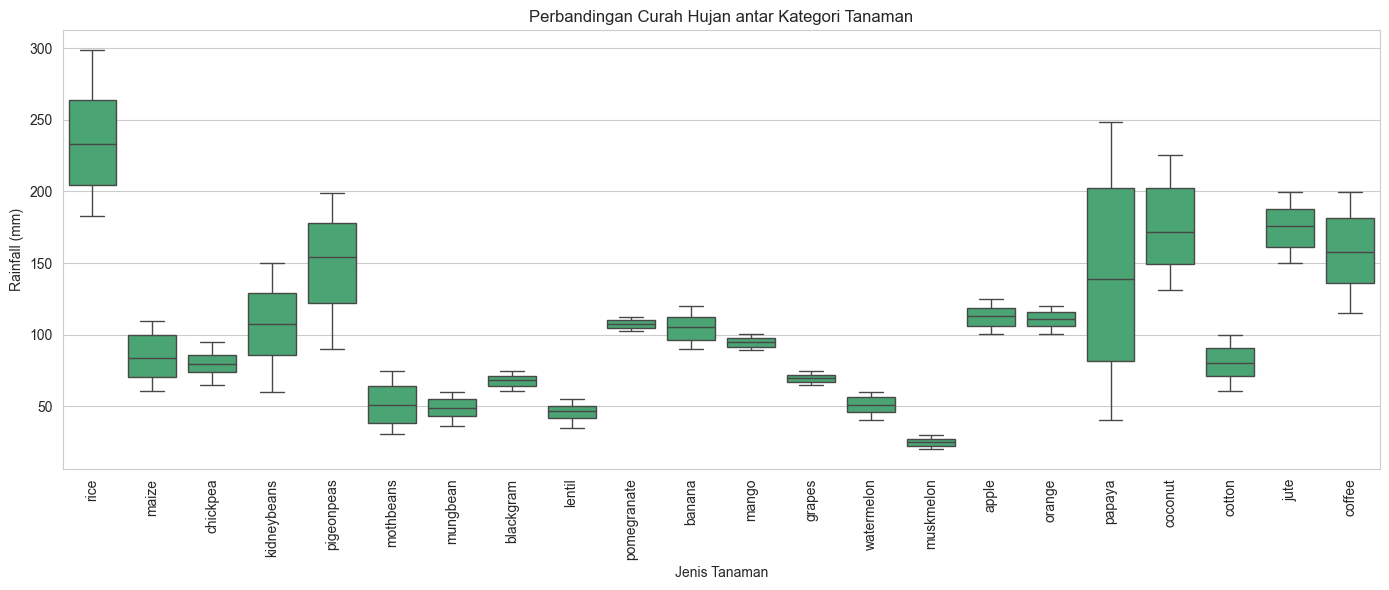

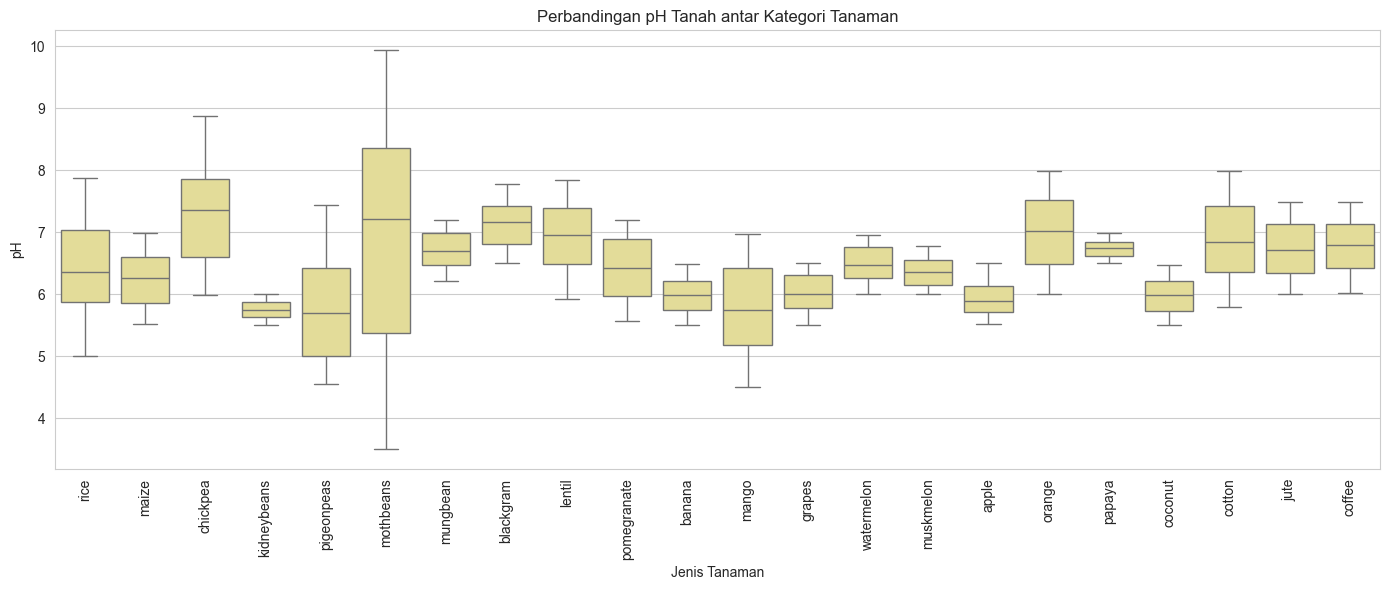

In [5]:

# Kelembapan per kategori
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="label",
    y="humidity",
    color="lightskyblue"
)

plt.title("Perbandingan Kelembapan antar Kategori Tanaman")
plt.xlabel("Jenis Tanaman")
plt.ylabel("Humidity (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Curah hujan per kategori
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="label",
    y="rainfall",
    color="mediumseagreen"
)

plt.title("Perbandingan Curah Hujan antar Kategori Tanaman")
plt.xlabel("Jenis Tanaman")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# pH per kategori
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="label",
    y="ph",
    color="khaki"
)

plt.title("Perbandingan pH Tanah antar Kategori Tanaman")
plt.xlabel("Jenis Tanaman")
plt.ylabel("pH")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [6]:

# Preprocessing
fitur_numerik = df[kolom_numerik]
fitur_kategorikal = df[["label"]]

print("Fitur numerik:", fitur_numerik.columns.tolist())
print("Fitur kategorikal:", fitur_kategorikal.columns.tolist())

# Encoding label
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label"])

pemetaan_label = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print("Pemetaan label:")
print(pemetaan_label)


Fitur numerik: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Fitur kategorikal: ['label']
Pemetaan label:
{'apple': 0, 'banana': 1, 'blackgram': 2, 'chickpea': 3, 'coconut': 4, 'coffee': 5, 'cotton': 6, 'grapes': 7, 'jute': 8, 'kidneybeans': 9, 'lentil': 10, 'maize': 11, 'mango': 12, 'mothbeans': 13, 'mungbean': 14, 'muskmelon': 15, 'orange': 16, 'papaya': 17, 'pigeonpeas': 18, 'pomegranate': 19, 'rice': 20, 'watermelon': 21}


Sebelum standardisasi:
mean    25.616244
std      5.063749
min      8.825675
max     43.675493
Name: temperature, dtype: float64

Sesudah standardisasi:
mean    3.875688e-16
std     1.000227e+00
min    -3.316592e+00
max     3.567190e+00
Name: temperature, dtype: float64


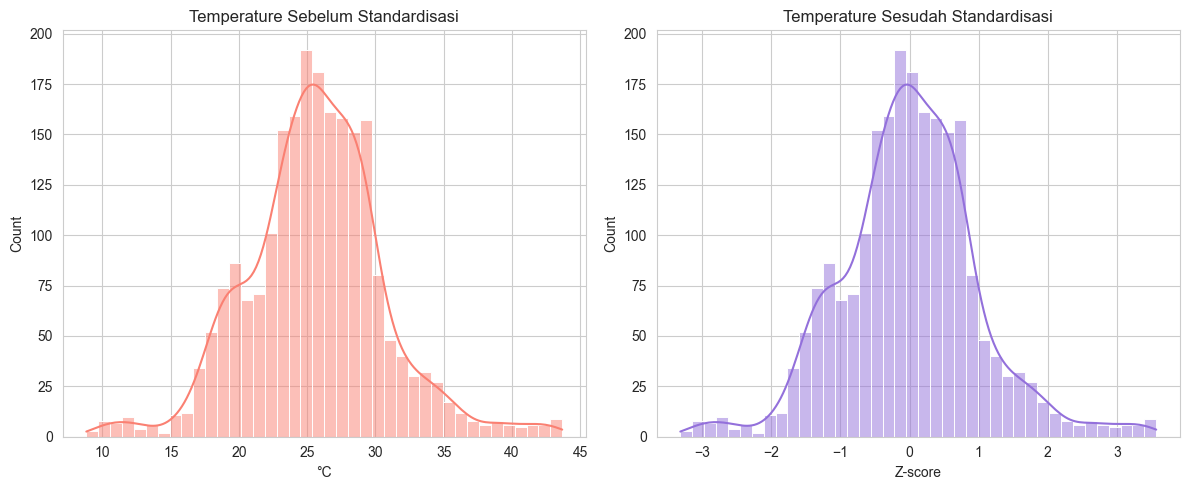

In [7]:

# Standardisasi
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

fitur_numerik_standar = pd.DataFrame(
    scaler.fit_transform(fitur_numerik),
    columns=kolom_numerik
)

print("Sebelum standardisasi:")
print(
    fitur_numerik["temperature"]
    .describe()[["mean", "std", "min", "max"]]
)

print("\nSesudah standardisasi:")
print(
    fitur_numerik_standar["temperature"]
    .describe()[["mean", "std", "min", "max"]]
)

# Perbandingan sebelum dan sesudah standardisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    fitur_numerik["temperature"],
    kde=True,
    ax=axes[0],
    color="salmon"
)
axes[0].set_title("Temperature Sebelum Standardisasi")
axes[0].set_xlabel("°C")

sns.histplot(
    fitur_numerik_standar["temperature"],
    kde=True,
    ax=axes[1],
    color="mediumpurple"
)
axes[1].set_title("Temperature Sesudah Standardisasi")
axes[1].set_xlabel("Z-score")

plt.tight_layout()
plt.show()

In [ ]:
# Machine Learning - Supervised (K-NN)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Menentukan fitur (X) dan target (y)
X = df[kolom_numerik]
y = df["label"]

print("Fitur (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print("label")

print("\nUkuran X:", X.shape)
print("Ukuran y:", y.shape)

NameError: name 'df' is not defined